## Model Selection
### Here we test each model accuracy by spliting between test and train , and then try to find out the best one
### The models we would be choosing from are : 
1. Logistic Regression
2. KNN
3. Decision Tree
4. Random Forest
5. SVM

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,precision_score, recall_score,f1_score,roc_curve, roc_auc_score

### Import Data

In [5]:
df_mobile_train = pd.read_csv("../data/raw/train.csv")
df_mobile_train.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [26]:

X= df_mobile_train.drop(columns='price_range')
y= df_mobile_train['price_range']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size= 0.2, random_state= 42, stratify= y)

In [7]:
results = []

## Logistic Regression 

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.fit_transform(X_test)


In [30]:
model= LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [32]:
y_pred= model.predict(X_test)
y_pred

array([3, 1, 0, 2, 3, 2, 0, 0, 1, 0, 3, 0, 0, 1, 3, 3, 2, 0, 1, 3, 1, 0,
       3, 2, 2, 1, 1, 0, 2, 1, 1, 2, 0, 2, 2, 3, 0, 3, 1, 0, 2, 0, 0, 2,
       3, 0, 3, 3, 2, 1, 0, 3, 0, 2, 0, 3, 3, 0, 2, 1, 1, 2, 3, 1, 0, 1,
       0, 1, 3, 3, 3, 2, 1, 1, 2, 0, 3, 3, 1, 3, 3, 2, 2, 0, 0, 1, 0, 0,
       0, 0, 0, 2, 2, 3, 0, 3, 0, 0, 2, 2, 3, 1, 1, 0, 3, 3, 1, 2, 1, 1,
       0, 2, 3, 1, 3, 2, 2, 2, 2, 2, 2, 0, 3, 0, 3, 3, 2, 0, 2, 3, 3, 0,
       0, 1, 3, 1, 2, 3, 2, 3, 3, 3, 2, 1, 3, 2, 1, 1, 0, 1, 3, 0, 1, 1,
       3, 3, 3, 2, 0, 2, 2, 0, 0, 3, 1, 1, 3, 1, 3, 0, 1, 1, 1, 3, 2, 1,
       1, 3, 0, 3, 2, 2, 2, 3, 0, 2, 0, 1, 1, 1, 0, 2, 1, 2, 3, 0, 2, 3,
       1, 1, 1, 2, 1, 2, 0, 0, 3, 1, 1, 2, 1, 3, 2, 0, 0, 3, 1, 2, 3, 3,
       0, 3, 3, 2, 2, 1, 1, 2, 1, 1, 0, 2, 0, 0, 0, 0, 0, 2, 2, 2, 2, 3,
       0, 1, 3, 2, 2, 3, 3, 2, 1, 0, 3, 3, 1, 3, 2, 2, 2, 2, 2, 2, 2, 1,
       0, 0, 3, 1, 2, 3, 3, 0, 0, 0, 1, 3, 2, 2, 3, 1, 3, 2, 2, 1, 1, 0,
       1, 1, 1, 3, 1, 0, 3, 1, 1, 1, 0, 1, 1, 1, 1,

### See Accuracy

In [33]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

Accuracy:  0.9625


### See confusion matrix

In [36]:
cm = confusion_matrix(y_test, y_pred)

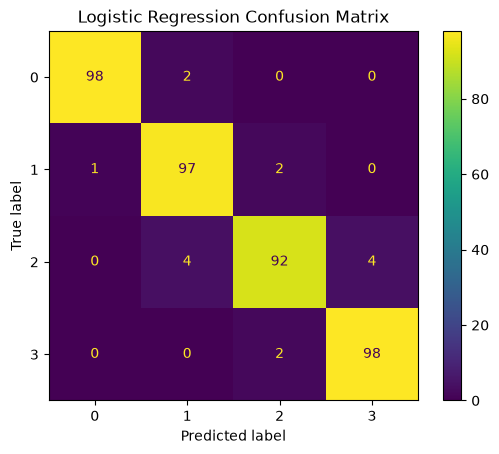

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1, 2, 3]
)

disp.plot()

plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [38]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

results.append({
    'model': 'Logistic Regression',
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1
})

Accuracy : 0.9625
Precision: 0.9626910524433369
Recall   : 0.9625
F1 Score : 0.9624155469132929
